In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
df = pd.read_csv("ai4i2020.csv")

df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.shape


(10000, 14)

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [6]:
df.describe()


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [8]:
df.isnull().sum().sum()


np.int64(0)

In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df["Machine failure"].value_counts()


Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
df["Machine failure"].value_counts(normalize=True) * 100


Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

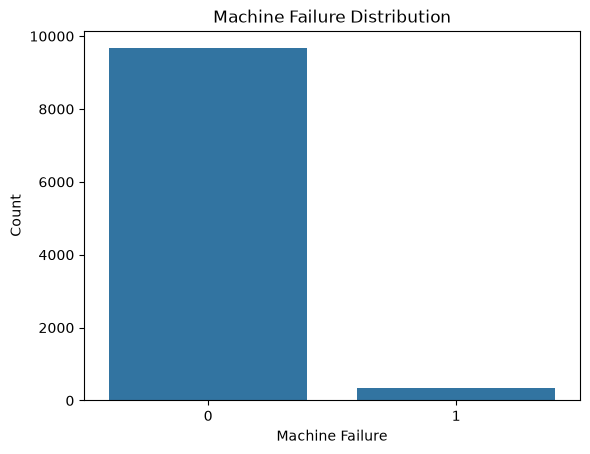

In [12]:
sns.countplot(x="Machine failure", data=df)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

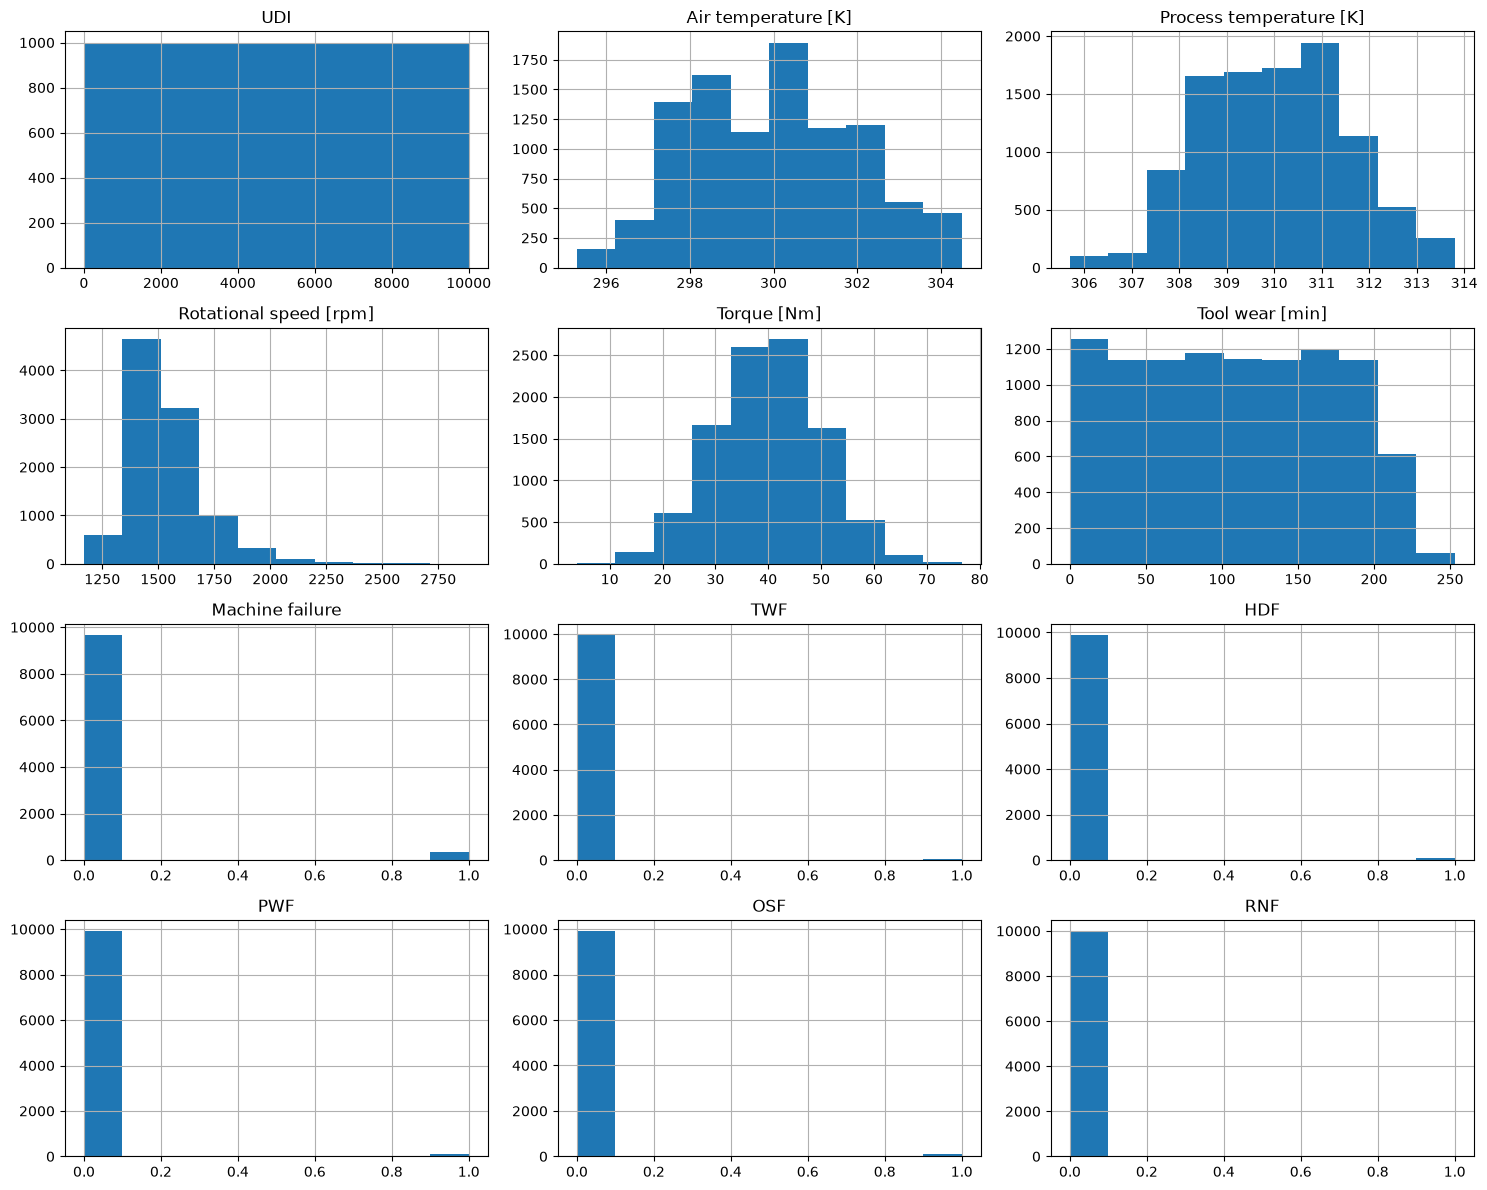

In [13]:
df.hist(figsize=(15, 12))

plt.tight_layout()
plt.show()

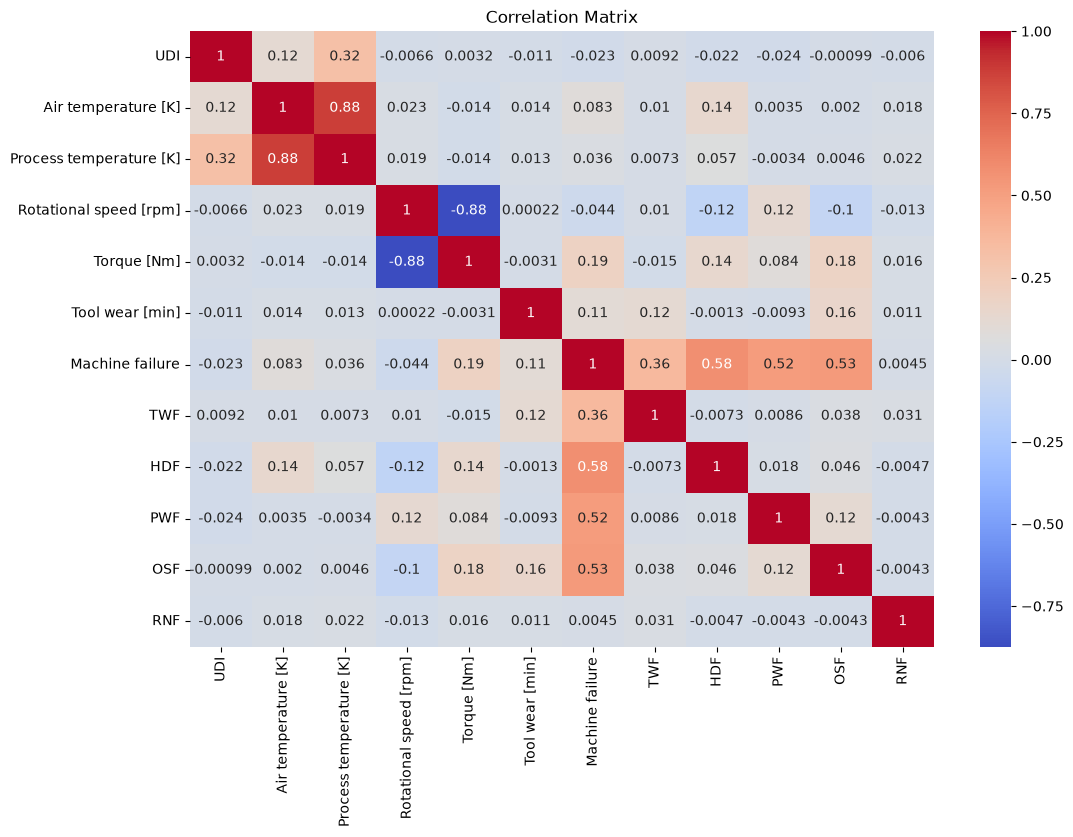

In [14]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

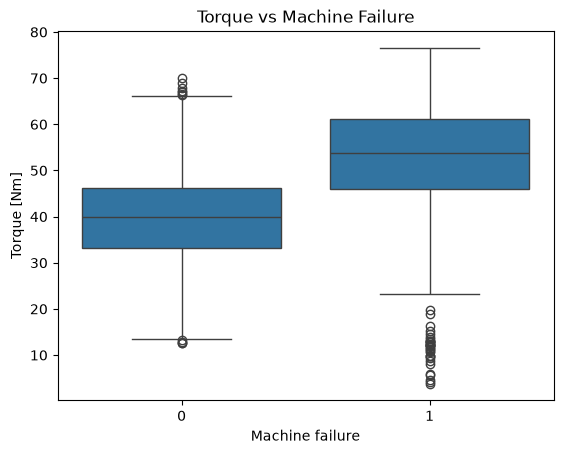

In [15]:
sns.boxplot(
    x="Machine failure",
    y="Torque [Nm]",
    data=df
)

plt.title("Torque vs Machine Failure")
plt.show()

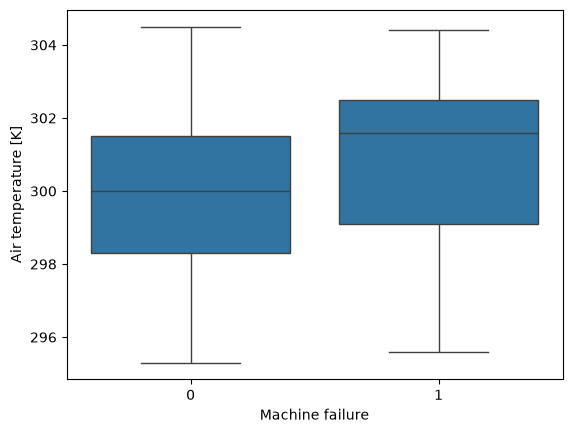

In [16]:
sns.boxplot(
    x="Machine failure",
    y="Air temperature [K]",
    data=df
)

plt.show()

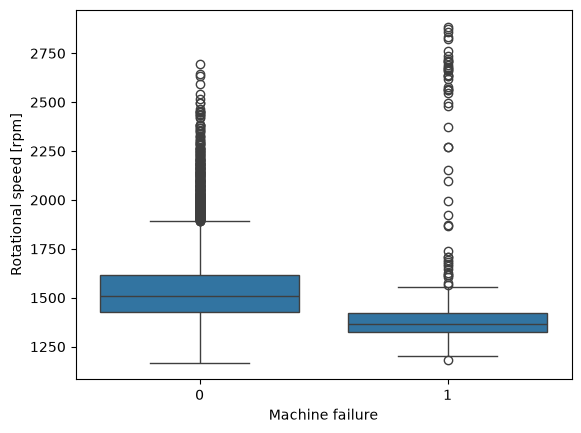

In [17]:
sns.boxplot(
    x="Machine failure",
    y="Rotational speed [rpm]",
    data=df
)

plt.show()

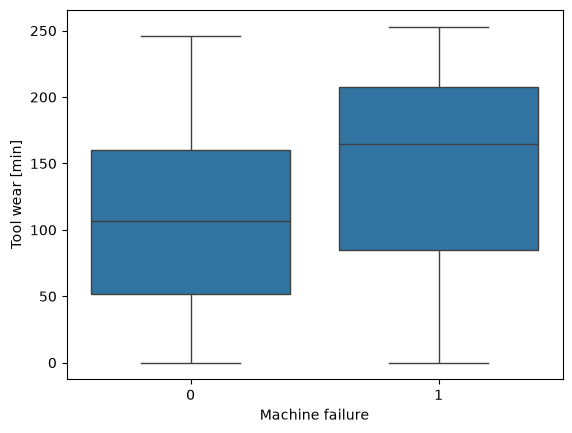

In [18]:
sns.boxplot(
    x="Machine failure",
    y="Tool wear [min]",
    data=df
)

plt.show()

In [19]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[features]

y = df["Machine failure"]

In [20]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [21]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

X shape: (10000, 6)
y shape: (10000,)

Features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target:
Machine failure


In [24]:
print(y.value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [25]:
print(y.value_counts(normalize=True) * 100)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 6)
Testing data: (2000, 6)


In [27]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [30]:
logistic_model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [31]:
y_pred = logistic_model.predict(X_test)

print(y_pred[:20])

[1 1 1 0 1 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0]


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8245
Precision: 0.14177215189873418
Recall   : 0.8235294117647058
F1 Score : 0.24190064794816415


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



In [34]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)

In [35]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Decision Tree Results
---------------------
Accuracy : 0.979
Precision: 0.7241379310344828
Recall   : 0.6176470588235294
F1 Score : 0.6666666666666666


In [36]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.72      0.62      0.67        68

    accuracy                           0.98      2000
   macro avg       0.86      0.80      0.83      2000
weighted avg       0.98      0.98      0.98      2000



In [37]:
cm_dt = confusion_matrix(y_test, dt_pred)

print(cm_dt)

[[1916   16]
 [  26   42]]


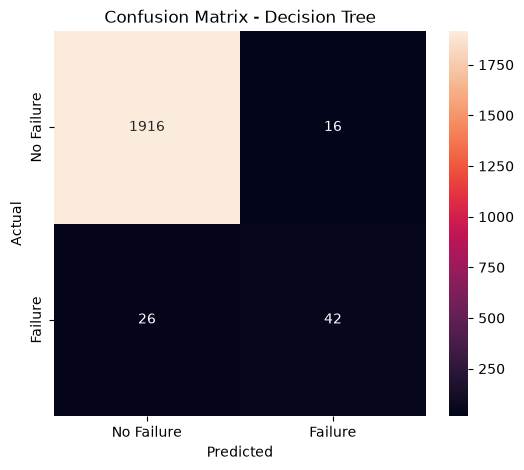

In [38]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [39]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [40]:
random_forest.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [41]:
rf_pred = random_forest.predict(X_test)

In [42]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Results
---------------------
Accuracy : 0.979
Precision: 0.703125
Recall   : 0.6617647058823529
F1 Score : 0.6818181818181818


In [43]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.70      0.66      0.68        68

    accuracy                           0.98      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [44]:
rf_prob = random_forest.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.9720991657532578


In [45]:
log_prob = logistic_model.predict_proba(X_test)[:, 1]
dt_prob = decision_tree.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, log_prob))

print("Decision Tree ROC-AUC:",
      roc_auc_score(y_test, dt_prob))

print("Random Forest ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

Logistic Regression ROC-AUC: 0.9069540859822189
Decision Tree ROC-AUC: 0.8046827426622823
Random Forest ROC-AUC: 0.9720991657532578


In [46]:
cm_rf = confusion_matrix(y_test, rf_pred)

print(cm_rf)

[[1913   19]
 [  23   45]]


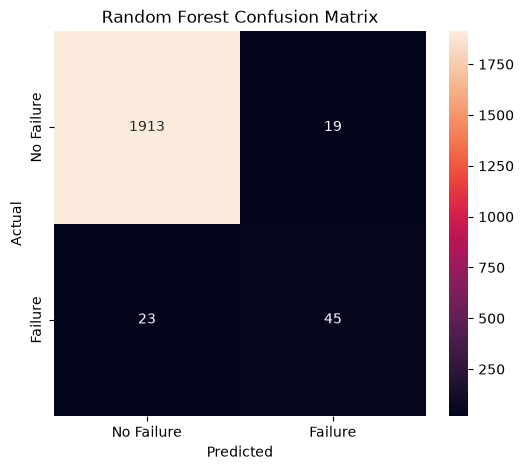

In [47]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

rf = random_forest.named_steps["classifier"]

feature_names = (
    random_forest.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

                              Feature  Importance
6              numerical__Torque [Nm]    0.305896
5   numerical__Rotational speed [rpm]    0.297352
7          numerical__Tool wear [min]    0.209390
3      numerical__Air temperature [K]    0.100740
4  numerical__Process temperature [K]    0.068782
1                 categorical__Type_L    0.008953
2                 categorical__Type_M    0.005809
0                 categorical__Type_H    0.003077


In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    random_forest,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("ROC-AUC scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

ROC-AUC scores: [0.97114531 0.95646465 0.97381942 0.96763107 0.96059402]
Mean ROC-AUC: 0.9659308945311851
Standard Deviation: 0.006486933510955589


In [90]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

In [91]:
grid_search = GridSearchCV(
    random_forest,
    param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10, ...], 'classifier__min_samples_leaf': [1, 2], 'classifier__min_samples_split': [2, 5], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parame

In [92]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.9718152095398104


In [93]:
best_rf = grid_search.best_estimator_

In [94]:
best_rf_pred = best_rf.predict(X_test)
best_rf_prob = best_rf.predict_proba(X_test)[:, 1]

In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, best_rf_pred))
print("Precision:", precision_score(y_test, best_rf_pred))
print("Recall:", recall_score(y_test, best_rf_pred))
print("F1 Score:", f1_score(y_test, best_rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_rf_prob))

Accuracy: 0.974
Precision: 0.5888888888888889
Recall: 0.7794117647058824
F1 Score: 0.6708860759493671
ROC-AUC: 0.962603519668737


In [96]:
from sklearn.metrics import confusion_matrix

cm_best = confusion_matrix(y_test, best_rf_pred)

print(cm_best)

[[1895   37]
 [  15   53]]


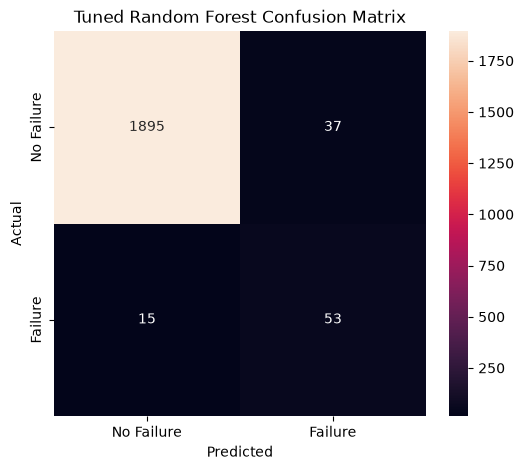

In [97]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_best,
    annot=True,
    fmt="d",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest Confusion Matrix")

plt.show()

In [99]:
import joblib

joblib.dump(
    best_rf,
    "machine_failure_random_forest.pkl"
)

print("Final corrected model saved successfully!")

Final corrected model saved successfully!


In [100]:
import os

print(os.path.exists("machine_failure_random_forest.pkl"))
print(os.path.getsize("machine_failure_random_forest.pkl"), "bytes")

True
6049522 bytes


In [101]:
import joblib

loaded_model = joblib.load(
    "machine_failure_random_forest.pkl"
)

print("Model loaded successfully!")

Model loaded successfully!


In [102]:
test_prediction = loaded_model.predict(X_test)

print(test_prediction[:10])

[1 0 0 0 0 0 0 0 0 0]
